# Overall Test-Set Performance Comparison
The master results table: Accuracy, macro Precision/Recall/F1, and macro AUC
for all 6 single models plus the proposed ensemble, in one place -- the
consolidated summary table most papers lead their Results section with.
Reuses cached predictions -- no models, no GPU needed.

## Cell 1 — Setup + load cached predictions

In [7]:
import numpy as np
import pandas as pd
import json as jsonlib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

from google.colab import drive
drive.mount('/content/drive')

cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

pred_swin = np.load(f'{cache}/pred_swin.npy')
pred_vit = np.load(f'{cache}/pred_vit.npy')
pred_resnet = np.load(f'{cache}/pred_resnet.npy')
pred_densenet = np.load(f'{cache}/pred_densenet.npy')
pred_efficientnet = np.load(f'{cache}/pred_efficientnet.npy')
pred_levit = np.load(f'{cache}/pred_levit.npy')
ensemble_probs = np.load(f'{cache}/ensemble_probs.npy')
true_labels = np.load(f'{cache}/true_labels.npy')
with open(f'{cache}/class_names.json') as f:
    class_names = jsonlib.load(f)

print("Loaded. Test set size:", len(true_labels))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded. Test set size: 2538


## Cell 2 — Build the master comparison table

In [8]:
all_models = {
    "Swin": pred_swin,
    "ViT": pred_vit,
    "LeViT": pred_levit,
    "ResNet50": pred_resnet,
    "DenseNet121": pred_densenet,
    "EfficientNetB0": pred_efficientnet,
    "Proposed Ensemble": ensemble_probs,
}

rows = []
for name, probs in all_models.items():
    pred_labels = np.argmax(probs, axis=1)
    acc = accuracy_score(true_labels, pred_labels)
    prec, rec, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='macro', zero_division=0)
    macro_auc = roc_auc_score(true_labels, probs, multi_class='ovr', average='macro')
    rows.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "Precision": round(prec * 100, 2),
        "Recall": round(rec * 100, 2),
        "F1-Score": round(f1 * 100, 2),
        "AUC": round(macro_auc, 4),
    })

master_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(master_df.to_string(index=False))

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
master_df.to_csv(f'{output_folder}/overall_performance_comparison.csv', index=False)
print(f"\nSaved to: {output_folder}/overall_performance_comparison.csv")

            Model  Accuracy  Precision  Recall  F1-Score    AUC
Proposed Ensemble     98.86      98.88   98.87     98.86 0.9998
             Swin     98.42      98.43   98.44     98.43 0.9998
              ViT     98.23      98.24   98.20     98.20 0.9998
         ResNet50     97.95      97.82   97.93     97.87 0.9995
   EfficientNetB0     97.68      97.52   97.58     97.54 0.9995
      DenseNet121     96.89      96.81   96.72     96.75 0.9994
            LeViT     95.15      95.28   95.01     95.13 0.9987

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/overall_performance_comparison.csv


## Cell 3 — Grouped bar chart (visual companion to the table)
Compact, paper-sized figure comparing Accuracy / Precision / Recall / F1
across all models (AUC is on a different scale, so it's left off this chart
-- it's already in the table).

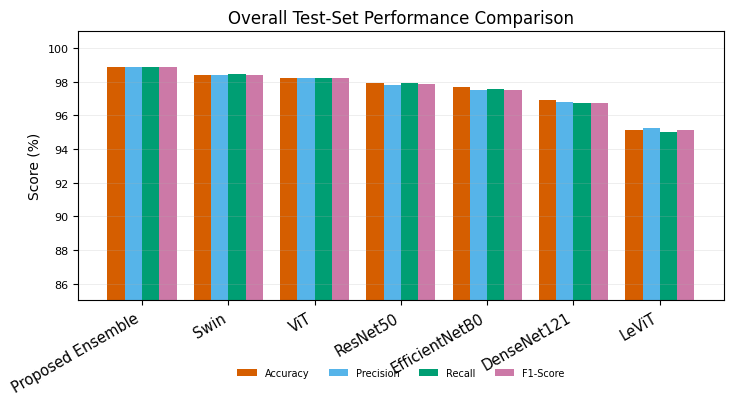

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/overall_performance_barchart.png


In [11]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_df = master_df.set_index("Model")[metrics]

x = np.arange(len(plot_df))
width = 0.2
fig, ax = plt.subplots(figsize=(7.5, 4.2))

colors = [
    '#D55E00',  # orange - Accuracy
    '#56B4E9',  # sky blue - Precision
    '#009E73',  # bluish green - Recall
    '#CC79A7',  # reddish purple - F1-Score

]
for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    is_ensemble = plot_df.index == "Proposed Ensemble"
    bars = ax.bar(x + offset, plot_df[metric], width, label=metric, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha='right', fontsize=10.5)
ax.set_ylabel('Score (%)', fontsize=10)
ax.set_ylim(85, 101)
ax.set_title('Overall Test-Set Performance Comparison', fontsize=12)
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=7, ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.32), frameon=False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{output_folder}/overall_performance_barchart.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/overall_performance_barchart.png")